In [1]:
import pandas as pd
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
import requests 
import os
import numpy as np
import pyarrow
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path



In [3]:
# Definition des dossiers
git_folder = "Patricia-Promise-Immo"
folder_entries = "data"
base_dir = Path().resolve().parents[1]
data_dir = base_dir/git_folder/folder_entries
if not data_dir.exists():
    data_dir.mkdir(parents=True)
print(f"Data directory is set to : {data_dir}")

Data directory is set to : D:\ProjectFolderDevAI_2025-2026\Immo_project\Patricia-Promise-Immo\data


In [4]:
# Liste des fichiers à télécharger par année via leurs URLs
DOWNLOADs_ = [
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234902/valeursfoncieres-2025-s1.txt.zip',
        'year' : '2025'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234857/valeursfoncieres-2024.txt.zip',
        'year' : '2024'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234851/valeursfoncieres-2023.txt.zip',
        'year' : '2023'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234844/valeursfoncieres-2022.txt.zip',
        'year' : '2022'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234836/valeursfoncieres-2021.txt.zip',
        'year' : '2021'
    },
    {
        'url' : 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20251018-234831/valeursfoncieres-2020-s2.txt.zip',
        'year' : '2020'
    }
    
    ]

# Téléchargement des fichiers par année
for immo_file in DOWNLOADs_ :
    response = requests.get(immo_file['url'], stream=True) #Stream = True afin d'éviter de tout charger en mémoire
    
    # Création du dossier 'raw' s'il n'existe pas pour stocker les fichiers téléchargés
    raw_dir = data_dir/"raw"
    if not raw_dir.exists():
        raw_dir.mkdir(parents=True)
        
    # Enregistrement du fichier par itérations
    with open(f"{raw_dir}/immo_entries_{immo_file['year']}.txt.zip", 'wb') as file:
        for chunk in response.iter_content(chunk_size=10_000):
            file.write(chunk)

print("Téléchargement terminé.")

Téléchargement terminé.


In [5]:
# Liste des fichiers téléchargés
all_immo_files = os.listdir(raw_dir)
print("Fichiers téléchargés :")
for f in all_immo_files:
    print(f" - {f}")    

Fichiers téléchargés :
 - immo_entries_2020.txt.zip
 - immo_entries_2021.txt.zip
 - immo_entries_2022.txt.zip
 - immo_entries_2023.txt.zip
 - immo_entries_2024.txt.zip
 - immo_entries_2025.txt.zip


In [ ]:
# Exploration d'un fichier téléchargé et conversion en DataFrame 
data_path = data_dir/"raw"
raw_path = data_path/"immo_entries_2024.txt.zip"
print(raw_path)
df = pd.read_csv(f"{raw_path}", nrows=200_000, on_bad_lines='skip', low_memory=False, sep='|', decimal=',', dtype={'Code postal':str, 'Valeur fonciere':np.float64})
df

D:\ProjectFolderDevAI_2025-2026\Immo_project\Patricia-Promise-Immo\data\raw\immo_entries_2024.txt.zip


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,02/01/2024,Vente,346.5,NaN,NaN,NaN,B020,LE DELIVRE,1230,CHALEY,1,76,NaN,B,514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,P,NaN,99.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,03/01/2024,Vente,10000.0,NaN,NaN,NaN,B007,CHEVRY DESSOUS,1170,CHEVRY,1,103,NaN,B,1782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,115.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,08/01/2024,Vente,249000.0,NaN,NaN,NaN,B086,PIN HAMEAU,1290,LAIZ,1,203,NaN,C,1065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,497.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2024,Vente,329500.0,29.0,NaN,PL,0500,DU JURA,1170,GEX,1,173,NaN,AI,551,NaN,175,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,NaN,89.0,4.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2024,Vente,329500.0,9001.0,NaN,PL,0500,DU JURA,1170,GEX,1,173,NaN,AI,551,NaN,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,23/12/2024,Vente en l'état futur d'achèvement,15389648.0,NaN,NaN,CHE,0903,DE SIDONIE,6700,SAINT LAURENT DU VAR,6,123,NaN,BH,341,NaN,801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,23/12/2024,Vente en l'état futur d'achèvement,15389648.0,NaN,NaN,CHE,0903,DE SIDONIE,6700,SAINT LAURENT DU VAR,6,123,NaN,BH,341,NaN,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,23/12/2024,Vente en l'état futur d'achèvement,15389648.0,NaN,NaN,CHE,0903,DE SIDONIE,6700,SAINT LAURENT DU VAR,6,123,NaN,BH,341,NaN,803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,23/12/2024,Vente en l'état futur d'achèvement,15389648.0,NaN,NaN,CHE,0903,DE SIDONIE,6700,SAINT LAURENT DU VAR,6,123,NaN,BH,341,NaN,804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
"""parquet_path= interim_dir/"all_immo_entries.parquet"
print(parquet_path)

writer = None

for index, chunk in enumerate(pd.read_csv(f"{output_path}", chunksize=10_000)):
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    
    # Initialise le writer une seule fois avec le schéma du premier chunk
    if writer is None:
        writer = pq.ParquetWriter(parquet_path, schema=table.schema, compression="snappy")
    
    # Écrit le chunk courant
    writer.write_table(table)

# Ferme le writer à la fin
if writer is not None:
    writer.close()"""



In [ ]:
!pip install missingno

<Axes: >

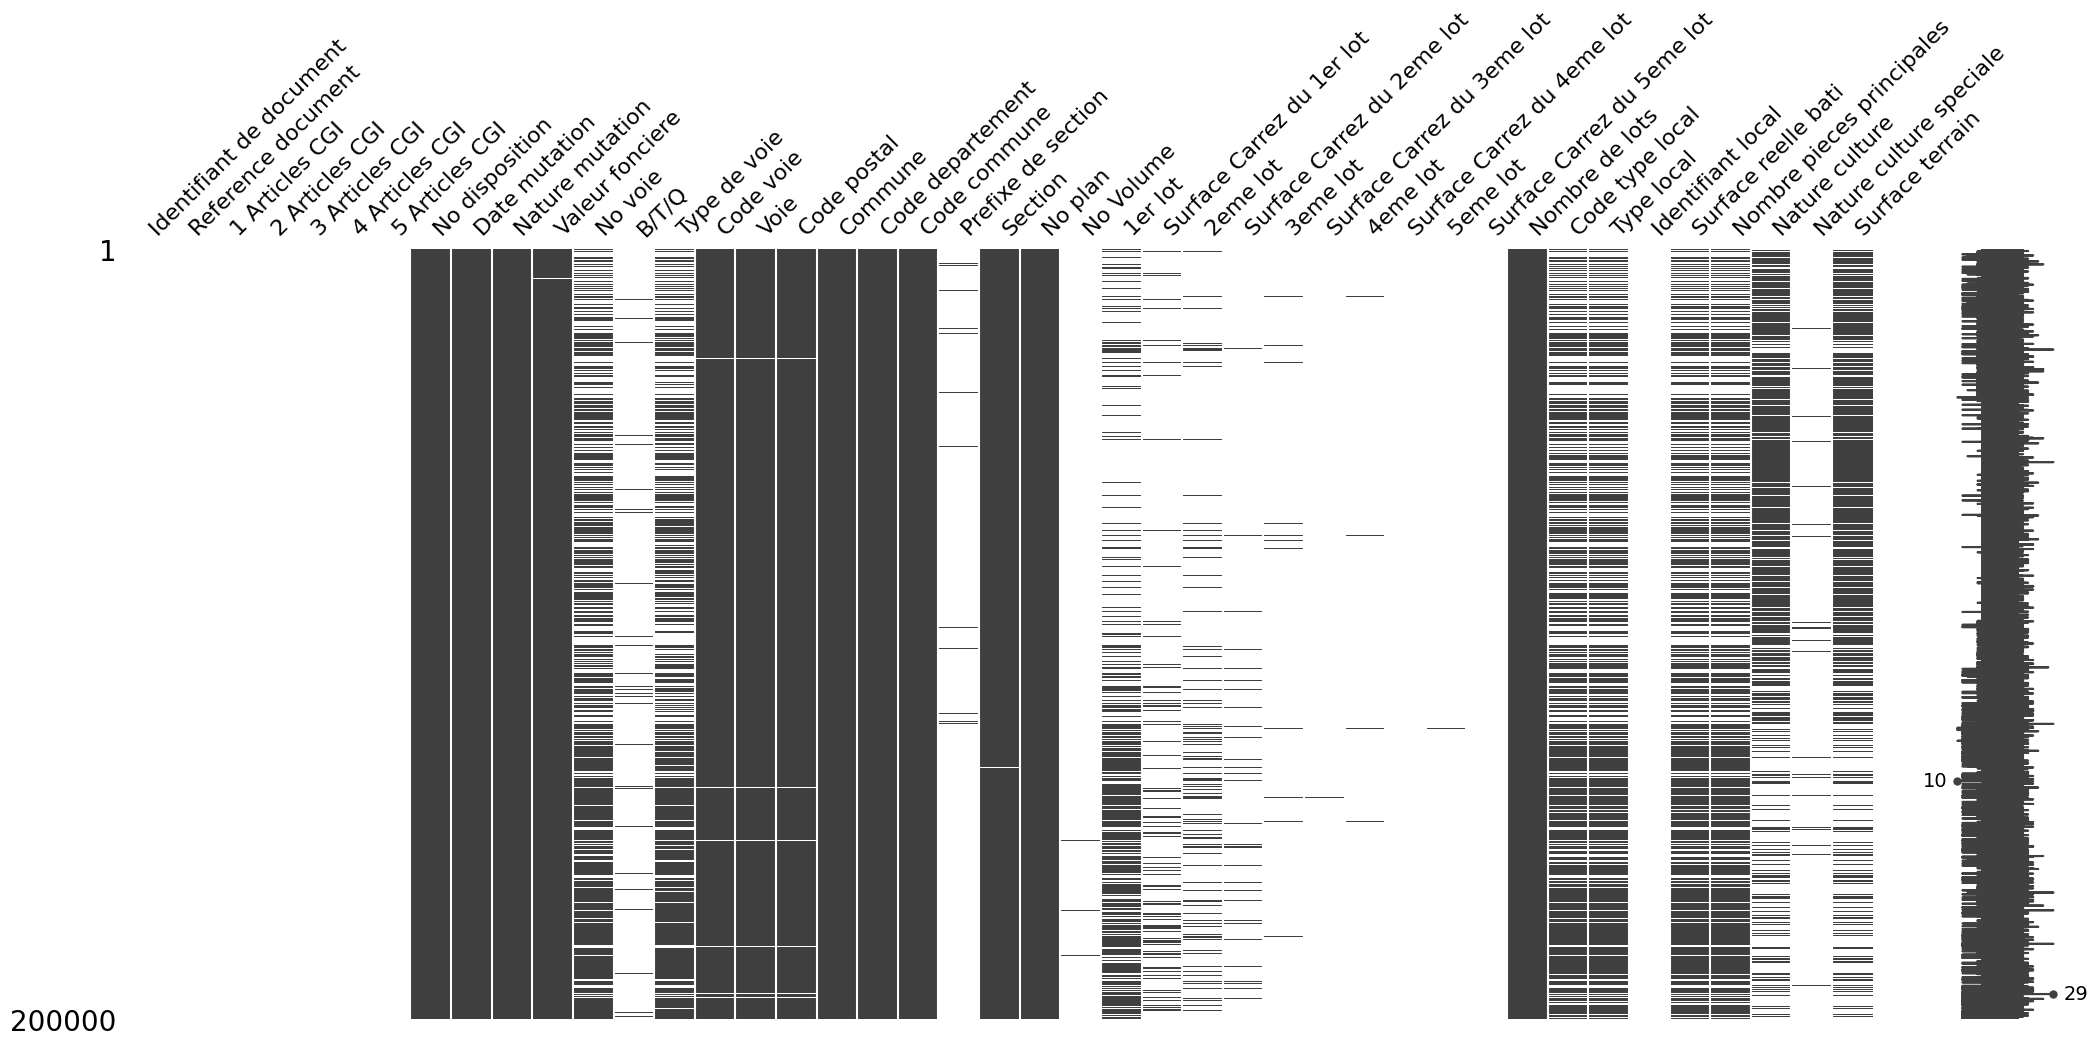

In [13]:
# Matrice des valeurs manquantes
import missingno as msno
msno.matrix(df)